In [1]:
from pathlib import Path
from references import references
from bamboo_hh_new.utils.histograms import get_total_hist, normalize_hist
from bamboo_hh_new.utils.analysis_config import AnalysisConfig

import mplhep
import numpy as np
import matplotlib.pyplot as plt

Welcome to JupyROOT 6.30/02


In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
plt.style.use(mplhep.style.CMS)
label_fontsize = 18
tick_fontsize = 18
rlabel = "13.6 TeV"
legend_fontsize = 18
cms_fontsize = 18

In [4]:
def hist_to_numpy(hist):
    values = np.array([hist.GetBinContent(i + 1) for i in range(hist.GetNbinsX())])
    edges = np.array([hist.GetBinLowEdge(i + 1) for i in range(hist.GetNbinsX() + 1)])
    return values, edges

def normalize(arr):
    return arr / np.sum(arr) if np.sum(arr) > 0 else arr

In [5]:
def plot_signal_background(normalized_signal, normalized_background):
    ylabel = "normalized events"
    rlabel = "13.6 TeV"

    sig_vals, edges = hist_to_numpy(normalized_signal)
    bkg_vals, _ = hist_to_numpy(normalized_background)

    fig, ax = plt.subplots(figsize=(6.5, 6))  # Square-ish

    ax.step(edges[:-1], sig_vals, where='post', color='blue', linewidth=2.0, label="Signal")
    ax.fill_between(edges[:-1], sig_vals, step='post', color='blue', alpha=0.2)

    ax.step(edges[:-1], bkg_vals, where='post', color='red', linewidth=2.0, label="Background")
    ax.fill_between(edges[:-1], bkg_vals, step='post', color='red', alpha=0.2)

    ax.set_xlabel(r"$m_{bb}$ (GeV)", fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_xlim(0, 300)
    ax.set_ylim(0, max(sig_vals.max(), bkg_vals.max()) * 1.2)
    ax.grid(True)

    ax.legend(fontsize=legend_fontsize, loc="upper right", frameon=True)

    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(
        1.0, 1.0, rlabel,
        transform=ax.transAxes,
        fontsize=cms_fontsize,
        horizontalalignment='right',
        verticalalignment='bottom'
    )

    fig.tight_layout()
    plt.show()

In [45]:
import json

def load_llr_mapping(json_path: str, name: str):
    with open(json_path, "r") as f:
        data = json.load(f)

    for corr in data["corrections"]:
        if corr["name"] == name:
            edges = np.array(corr["data"]["edges"])
            values = np.array(corr["data"]["content"])
            return edges, values
    raise ValueError(f"Mapping '{name}' not found in file.")

def plot_llr(ratio_hist, mapping_path, corr_name):

    ratio_vals, edges = hist_to_numpy(ratio_hist)
    llr_vals = np.log(ratio_vals) 

    # Load the mapping
    mapping_edges, mapping_vals = load_llr_mapping(mapping_path, corr_name)

    fig, ax = plt.subplots(figsize=(6.5, 6))

    # Histogram-based LLR
    ax.step(
        edges[:-1],
        llr_vals,
        where='post',
        color='green',
        linewidth=2.0,
        alpha=0.7,
        label='Binned LLR'
    )
    # Mapping-based LLR
    ax.step(
        mapping_edges[:-1],
        mapping_vals,
        where='post',
        color='purple',
        linestyle='-',
        linewidth=2.5,
        alpha=0.6,
        label='Interpolated LLR'
    )
    ax.set_xlabel(r"$m_{bb}$ (GeV)", fontsize=label_fontsize)
    ax.set_ylabel(r"LLR$(m_{bb})$", fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_xlim(0, 300)
    ax.grid(True)

    ax.legend(fontsize=legend_fontsize, loc='lower right', frameon=True)

    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(
        1.0, 1.0, rlabel,
        transform=ax.transAxes,
        fontsize=cms_fontsize,
        horizontalalignment='right',
        verticalalignment='bottom'
    )

    fig.tight_layout()
    plt.show()


### Era2022_0215_HHttbartW/Reco_even

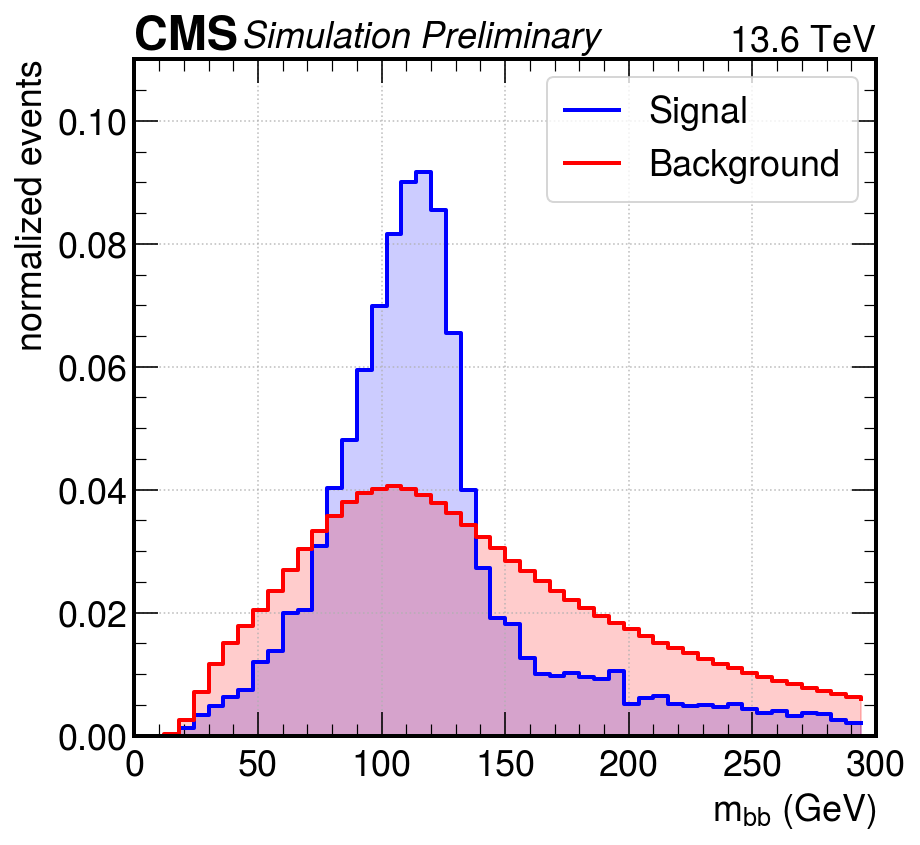

/tmp/anunezde/ipykernel_2664306/4103961221.py:17: RuntimeWarning: divide by zero encountered in log
  llr_vals = np.log(ratio_vals)


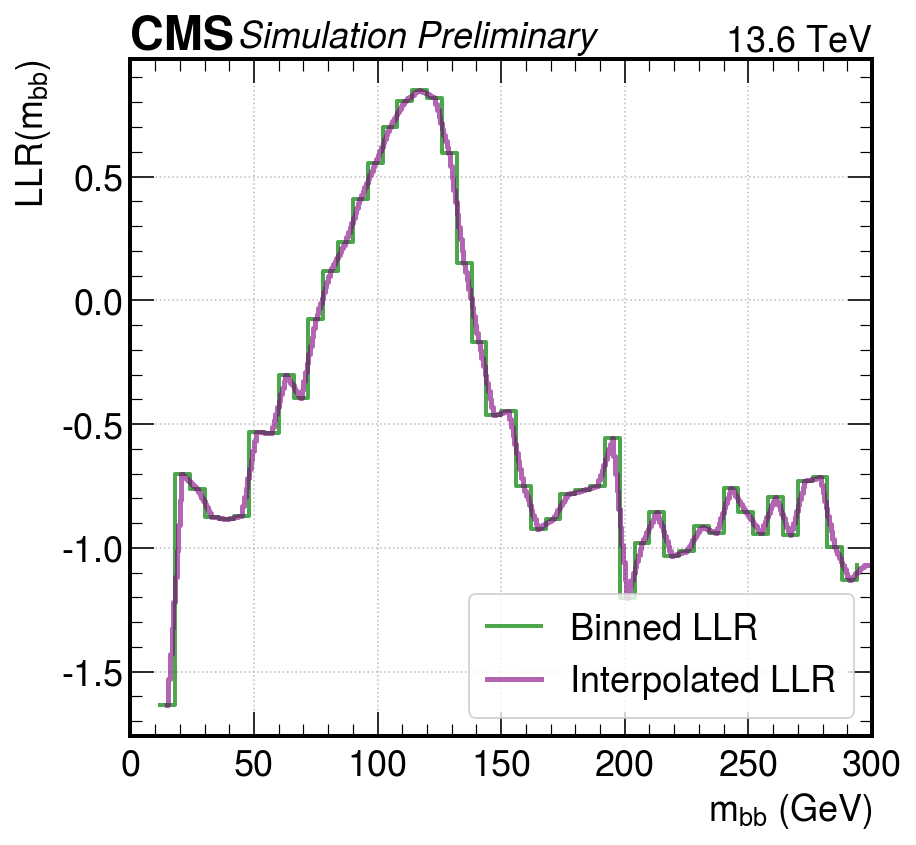

0.00334825583
0.000777396389
366
88.4


In [46]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos_archived/Era2022_0215_HHttbartW/Reco_even')
resultsdir = workdir / 'results'

var_name = 'bjets_mbb'
selection = 'SL_resolved'

ref = '_'.join([selection, var_name])

signal_filenames = ['bbWW_sl_2022', 'bbWW_dl_2022']
background_filenames = [
    'TTbar_sl_2022', 'TTbar_dl_2022', 
    'tbarWplus_sl_2022', 'tbarWplus_dl_2022', 
    'tWminus_sl_2022', 'tWminus_dl_2022']
signal_files = references.get_files(resultsdir, signal_filenames)
background_files = references.get_files(resultsdir, background_filenames)

config = AnalysisConfig(Path('/afs/cern.ch/user/a/anunezde/bamboodev/hh/bamboo_hh_new/config/analysis_dev_nn_lrStudy.yml'))
signal_hist = get_total_hist(ref, signal_files, config)
background_hist = get_total_hist(ref, background_files, config)
normalized_signal = normalize_hist(signal_hist)
normalized_background = normalize_hist(background_hist)
plot_signal_background(normalized_signal,  normalized_background)

mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos_archived/Era2022_0215_HHttbartW/Reco_even/results/corrections_llr_All.json')
corr_name = ref
ratio_hist = normalized_signal.Clone()
ratio_hist.Divide(normalized_background)
plot_llr(ratio_hist, mapping_path, f"{corr_name}_llr")

print(config.get_cross_section('bbWW_sl'))
print(config.get_cross_section('bbWW_dl'))
print(config.get_cross_section('TTbar_sl'))
print(config.get_cross_section('TTbar_dl'))

### JetTop

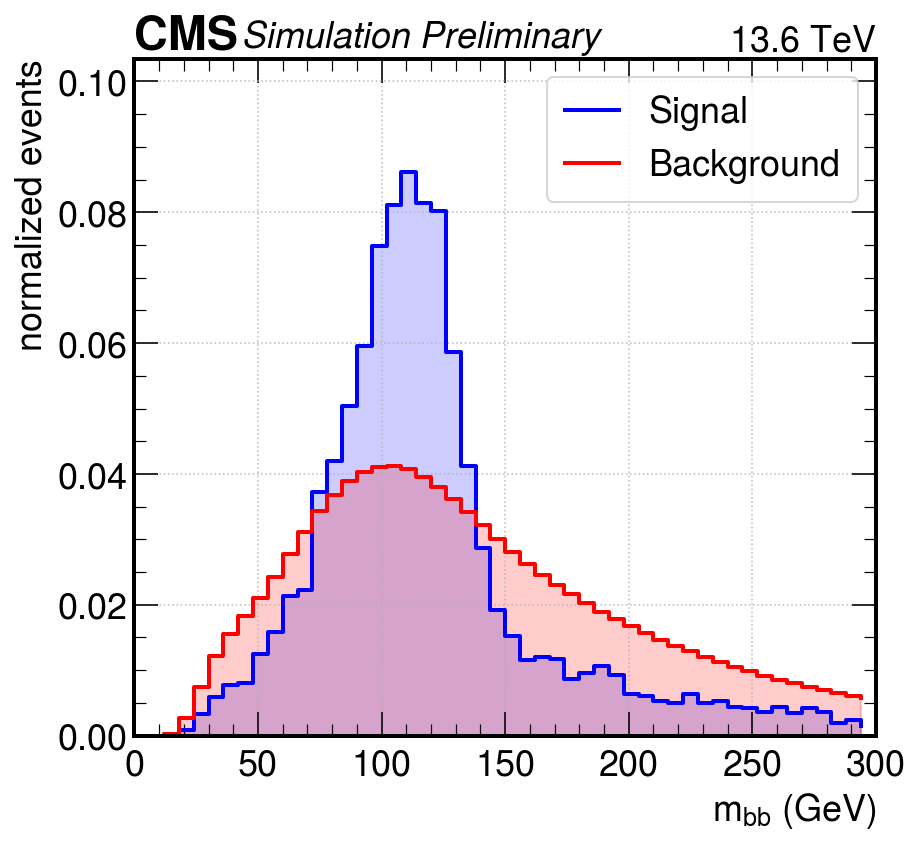

/tmp/anunezde/ipykernel_2664306/4103961221.py:17: RuntimeWarning: divide by zero encountered in log
  llr_vals = np.log(ratio_vals)


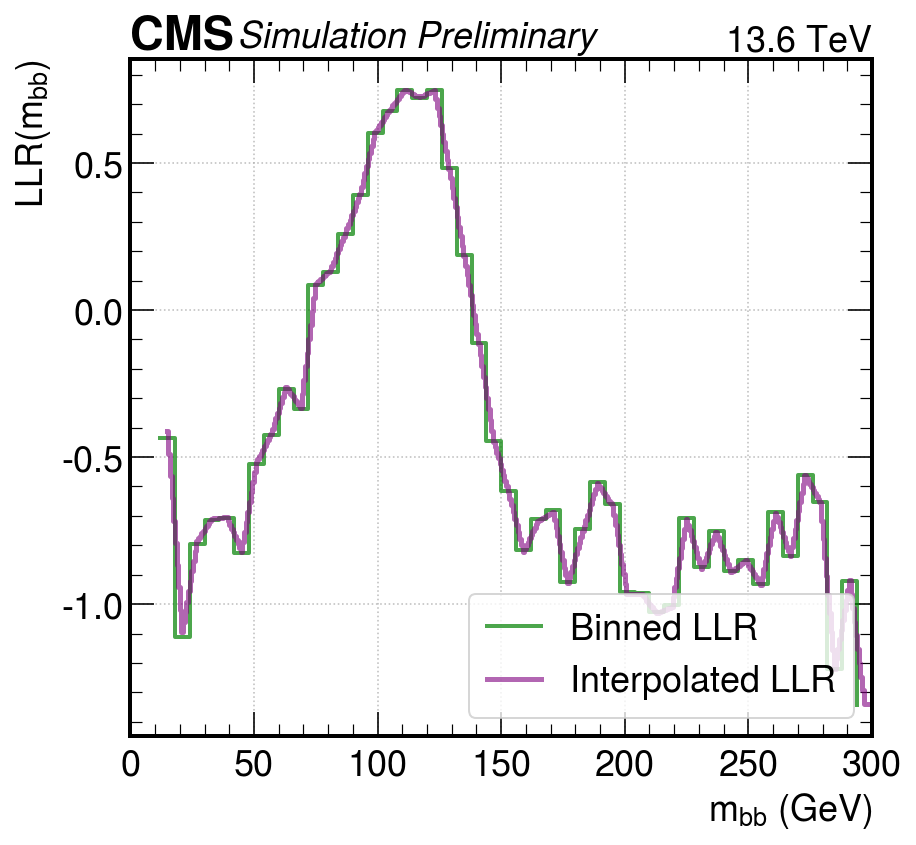

0.003776
0.000948
407.8
101.8


In [47]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/JetTop')
resultsdir = workdir / 'results'

var_name = 'bjets_mbb'
selection = 'SL_4j_resolved'

ref = '_'.join([selection, var_name])

signal_filenames = ['ggHH_kl_1_kt_1_bbww_sl_2022', 'ggHH_kl_1_kt_1_bbww_dl_2022']
background_filenames = [
    'ttbar_sl_2022', 'ttbar_dl_2022',
    'tbarWplus_sl_2022', 'tbarWplus_dl_2022', 
    'tWminus_sl_2022', 'tWminus_dl_2022']
signal_files = references.get_files(resultsdir, signal_filenames)
background_files = references.get_files(resultsdir, background_filenames)

config = AnalysisConfig()
signal_hist = get_total_hist(ref, signal_files, config)
background_hist = get_total_hist(ref, background_files, config)
normalized_signal = normalize_hist(signal_hist)
normalized_background = normalize_hist(background_hist)
plot_signal_background(normalized_signal,  normalized_background)

mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/JetTop/lr_mappings_log.json')
corr_name = ref
ratio_hist = normalized_signal.Clone()
ratio_hist.Divide(normalized_background)
plot_llr(ratio_hist, mapping_path, f"{corr_name}_llr")

print(config.get_cross_section('ggHH_kl_1_kt_1_bbww_sl'))
print(config.get_cross_section('ggHH_kl_1_kt_1_bbww_dl'))
print(config.get_cross_section('ttbar_sl'))
print(config.get_cross_section('ttbar_dl'))